## Improrting libraries

In [1]:
!pip install tensorflow
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

Mounted at /content/drive


## Importing the datasets

### Dataset stratification

In [3]:
# !pip install split-folders

In [4]:
# import splitfolders
# import os

In [5]:
# input_folder = '/content/drive/MyDrive/ml-datasets/painters/resized_training'
# output_folder = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset'

# split_ratio = (0.8, 0.1, 0.1)

# splitfolders.ratio(
#     input_folder,
#     output=output_folder,
#     seed=42,
#     ratio=split_ratio,
#     group_prefix=None,
#     move=False
# )

### Tensorflow datasets imports

In [6]:
train_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/train'
val_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/val'
test_directory = '/content/drive/MyDrive/ml-datasets/painters/stratified_dataset/test'

train = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=64,
    image_size=(224, 224),
    verbose=True
)

val = tf.keras.preprocessing.image_dataset_from_directory(
    val_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=64,
    image_size=(224, 224),
    verbose=True
)

test = tf.keras.preprocessing.image_dataset_from_directory(
    test_directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    seed=42,
    shuffle=True,
    batch_size=64,
    image_size=(224, 224),
    verbose=True
)

class_names = train.class_names
print(class_names)

Found 2456 files belonging to 27 classes.
Found 296 files belonging to 27 classes.
Found 327 files belonging to 27 classes.
['Caravaggio', 'Claude_Monet', 'Coriano', 'Diego_Rivera', 'Edouard_Manet', 'El_Greco', 'Eugene_Delacroix', 'Francisco_Goya', 'Frida_Kahlo', 'Gentullicci', 'Giotto_di_Bondone', 'Henri_Rousseau', 'Hieronymus_Bosch', 'Pablo_Picasso', 'Peter_Paul_Rubens', 'Pierre-Auguste_Renoir', 'Platin', 'Raphael', 'Rembrandt', 'Rene_Magritte', 'Rosemary', 'Roux', 'Salvador_Dali', 'Sandro_Botticelli', 'Titian', 'Valois', 'Vincent_van_Gogh']


In [7]:
# class_names = train.class_names
# print(len(class_names))

# plt.figure(figsize=(10, 10))
# for images, labels in train.take(1):
#   for i in range(9):
#     ax = plt.subplot(3, 3, i + 1)
#     plt.imshow(images[i].numpy().astype("uint8"))
#     plt.title(class_names[labels[i]])
#     plt.axis("off")
#   break

# CNN Implementation

## Finding the best model

In [8]:
def model_builder(hp):
  # Define the model's input
  inputs = keras.Input(shape=(224, 224, 3))

  # Apply data augmentation layers sequentially to the tensor
  x = keras.layers.RandomFlip("horizontal") (inputs)
  x = keras.layers.RandomRotation(0.03)(x)
  x = keras.layers.RandomCrop(224, 224)(x)
  x = keras.layers.RandomZoom((-0.25, 0.25), (-0.25, 0.25))(x)
  x = keras.layers.GaussianNoise(0.05)(x)
  x = keras.layers.RandomContrast(0.15)(x)
  x = keras.layers.RandomBrightness(0.15)(x)


  # Load the base model and set it to non-trainable
  base_model = tf.keras.applications.EfficientNetB0(
      include_top=False,
      input_shape=(224, 224, 3),
      pooling='avg',
  )
  base_model.trainable = False

  # Pass the augmented input tensor to the base_model
  x = base_model(x)

  # Add custom top layers
  hp_dropout = hp.Choice('dropout', values=[0.2, 0.25, 0.3, 0.35])
  x = tf.keras.layers.Dropout(hp_dropout)(x)
  outputs = tf.keras.layers.Dense(27, activation='softmax')(x)

  # Create the final model
  model = tf.keras.Model(inputs=inputs, outputs=outputs)

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-1, 1e-2, 1e-3, 1e-4])
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
      metrics=['accuracy']
  )

  return model

In [9]:
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory='my_dir',
    project_name='best_params',
    overwrite=True
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

tuner.search(x=train, validation_data=val, callbacks=[stop_early])


Trial 16 Complete [00h 00m 36s]
val_accuracy: 0.2432432472705841

Best val_accuracy So Far: 0.6722972989082336
Total elapsed time: 00h 26m 21s


In [10]:
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_params.values)

{'dropout': 0.2, 'learning_rate': 0.01, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0}


## Testing the model with the best parameters

In [14]:
best_params = {'dropout': 0.2, 'learning_rate': 0.01, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0}

inputs = keras.Input(shape=(224, 224, 3))

x = keras.layers.RandomFlip("horizontal") (inputs)
x = keras.layers.RandomRotation(0.03)(x)
x = keras.layers.RandomCrop(224, 224)(x)
x = keras.layers.RandomZoom((-0.25, 0.25), (-0.25, 0.25))(x)
x = keras.layers.GaussianNoise(0.05)(x)
x = keras.layers.RandomContrast(0.15)(x)
x = keras.layers.RandomBrightness(0.15)(x)

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg',
)
base_model.trainable = False

x = base_model(x)

x = tf.keras.layers.Dropout(best_params.get('dropout'))(x)
outputs = tf.keras.layers.Dense(27, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params.get('learning_rate')),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

callback_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='tmp/checkpoints/model{epoch:02d}.keras',
    verbose=1
)

callback_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1
)

history = model.fit(x=train, validation_data=val, epochs=50, callbacks=[callback_model_checkpoint, callback_early_stopping])

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.3515 - loss: 2.3779
Epoch 1: saving model to tmp/checkpoints/model01.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 323ms/step - accuracy: 0.3545 - loss: 2.3663 - val_accuracy: 0.6081 - val_loss: 1.2901
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6998 - loss: 0.9689
Epoch 2: saving model to tmp/checkpoints/model02.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 251ms/step - accuracy: 0.7000 - loss: 0.9689 - val_accuracy: 0.6486 - val_loss: 1.0685
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7662 - loss: 0.7517
Epoch 3: saving model to tmp/checkpoints/model03.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - accuracy: 0.7658 - loss: 0.7520 - val_accuracy: 0.6757 - val_loss: 1.0990
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8091 - loss: 0.5977
Epoch 4: saving model to tmp/checkpoints/model04.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 260ms/step - accuracy: 0.8087 - loss: 0.5988 - val_

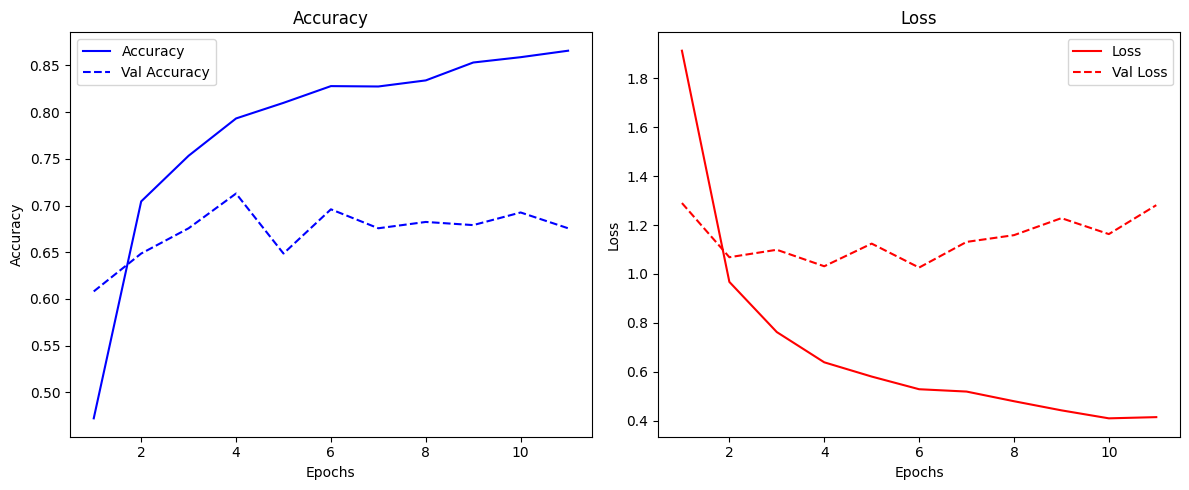

In [15]:
# 'history' is the History object returned by model.fit()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Accuracy')          # blue solid
plt.plot(epochs, val_acc, 'b--', label='Val Accuracy') # blue dotted
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r-', label='Loss')             # red solid
plt.plot(epochs, val_loss, 'r--', label='Val Loss')    # red dotted
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
new_model = keras.models.load_model('/content/tmp/checkpoints/model04.keras')
base_model = new_model.layers[8]

#fine tuning the base model
for layer in base_model.layers[-15:]:
    layer.trainable = True

new_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.005),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = new_model.fit(
    x=train,
    validation_data=val,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            filepath='tmp/final/model{epoch:02d}.keras',
            verbose=1
        ),
        callback_early_stopping
])

new_model.evaluate(test)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.5961 - loss: 1.4936
Epoch 1: saving model to tmp/final/model01.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 333ms/step - accuracy: 0.5959 - loss: 1.4940 - val_accuracy: 0.5135 - val_loss: 4.4534
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7699 - loss: 0.7131
Epoch 2: saving model to tmp/final/model02.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.7703 - loss: 0.7125 - val_accuracy: 0.6926 - val_loss: 1.9067
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8543 - loss: 0.4183
Epoch 3: saving model to tmp/final/model03.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.8541 - loss: 0.4193 - val_accuracy: 0.6520 - val_loss: 2.2390
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.8763 - loss: 0.3895
Epoch 4: saving model to tmp/final/model04.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.8764 - loss: 0.3892 - val_accuracy: 0.7027 - val_l

[1.637181043624878, 0.7339449524879456]

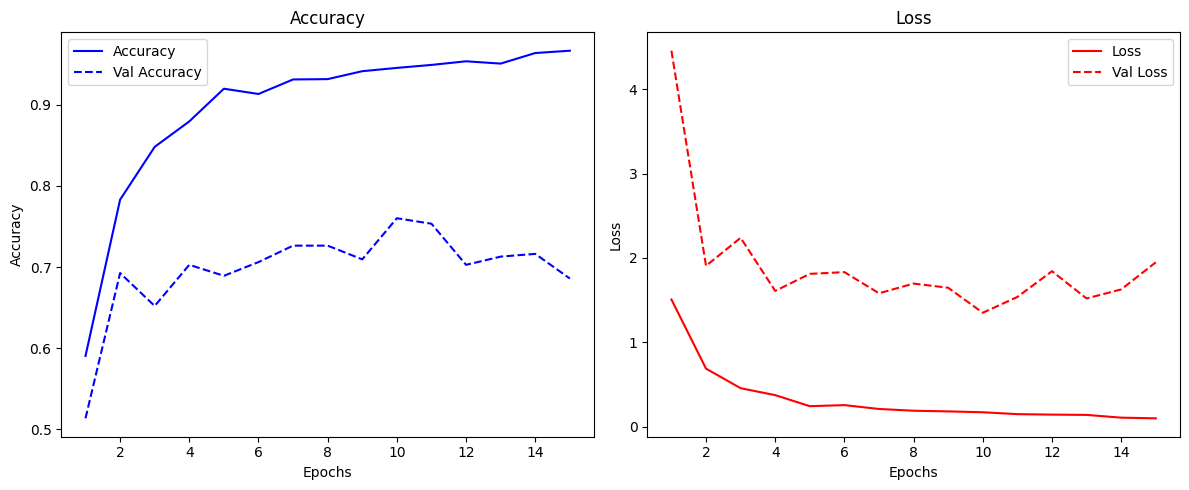

In [23]:
# 'history' is the History object returned by model.fit()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Accuracy')          # blue solid
plt.plot(epochs, val_acc, 'b--', label='Val Accuracy') # blue dotted
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r-', label='Loss')             # red solid
plt.plot(epochs, val_loss, 'r--', label='Val Loss')    # red dotted
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [24]:
final_model = keras.models.load_model('/content/tmp/final/model10.keras')
final_model.evaluate(test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.7311 - loss: 1.4954


[1.3739256858825684, 0.7339449524879456]

## Final 10 model builds on randomized datasets

In [ ]:
results = 0

for i in range(10):
  directory = '/content/drive/MyDrive/ml-datasets/painters/resized_training'

  train = tf.keras.preprocessing.image_dataset_from_directory(
      directory,
      labels='inferred',
      label_mode='int',
      color_mode='rgb',
      validation_split=0.2,
      subset='training',
      seed=i,
      shuffle=True,
      batch_size=64,
      image_size=(224, 224),
      verbose=True
  )

  test = tf.keras.preprocessing.image_dataset_from_directory(
      directory,
      labels='inferred',
      label_mode='int',
      color_mode='rgb',
      validation_split=0.2,
      subset='validation',
      seed=i,
      shuffle=True,
      batch_size=64,
      image_size=(224, 224),
      verbose=True
  )

  inputs = keras.Input(shape=(224, 224, 3))

  x = keras.layers.RandomFlip("horizontal") (inputs)
  x = keras.layers.RandomRotation(0.03)(x)
  x = keras.layers.RandomCrop(224, 224)(x)
  x = keras.layers.RandomZoom((-0.25, 0.25), (-0.25, 0.25))(x)
  x = keras.layers.GaussianNoise(0.05)(x)
  x = keras.layers.RandomContrast(0.15)(x)
  x = keras.layers.RandomBrightness(0.15)(x)

  base_model = tf.keras.applications.EfficientNetB0(
      include_top=False,
      input_shape=(224, 224, 3),
      pooling='avg',
  )
  base_model.trainable = False

  x = base_model(x)

  x = tf.keras.layers.Dropout(best_params.get('dropout'))(x)
  outputs = tf.keras.layers.Dense(27, activation='softmax')(x)

  model = tf.keras.Model(inputs=inputs, outputs=outputs)
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=best_params.get('learning_rate')),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
      metrics=['accuracy']
  )

  history = model.fit(x=train, validation_data=val, epochs=4)

  base_model = model.layers[8]

  #fine tuning the base model efficientNetB0
  for layer in base_model.layers[-15:]:
      layer.trainable = True

  model.compile(
      optimizer=tf.keras.optimizers.Adam(0.005),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
      metrics=['accuracy']
  )

  history = model.fit(
      x=train,
      validation_data=val,
      epochs=10
  )

  results+= model.evaluate(test)[1]

print('Average accuracy of 10 models :', results/10)

Found 3079 files belonging to 27 classes.
Using 2464 files for training.
Found 3079 files belonging to 27 classes.
Using 615 files for validation.
Epoch 1/4
 8/39 ━━━━━━━━━━━━━━━━━━━━ 5:28 11s/step - accuracy: 0.1869 - loss: 2.9831

In [ ]:
import os
import pandas as pd
import numpy as np

folder_name = ''

prediction_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    folder_name,
    labels=None,
    label_mode=None,
    color_mode='rgb',
    batch_size=64,
    image_size=(224, 224),
    verbose=True
)

class_names = ['Caravaggio', 'Claude_Monet', 'Coriano', 'Diego_Rivera', 'Edouard_Manet', 'El_Greco', 'Eugene_Delacroix', 'Francisco_Goya', 'Frida_Kahlo', 'Gentullicci', 'Giotto_di_Bondone', 'Henri_Rousseau', 'Hieronymus_Bosch', 'Pablo_Picasso', 'Peter_Paul_Rubens', 'Pierre-Auguste_Renoir', 'Platin', 'Raphael', 'Rembrandt', 'Rene_Magritte', 'Rosemary', 'Roux', 'Salvador_Dali', 'Sandro_Botticelli', 'Titian', 'Valois', 'Vincent_van_Gogh']

image_paths = prediction_dataset.file_paths
model = keras.models.load_model('/content/best_model.keras')

predictions = model.predict(prediction_dataset)
predictions_output = []

for i in predictions:
  predicted_class = np.argmax(predictions)
  predictions_output.append(predicted_class)

image_names = [os.path.basename(path) for path in image_paths]

# Create the DataFrame
results_df = pd.DataFrame({
    'Image Name': image_names,
    'Prediction': predictions_output
})

# Save the DataFrame to a CSV file
results_df.to_csv('image_predictions.csv', index=False)